In [ ]:
# >>> repo path setup (auto-added during reorg; keeps this notebook runnable from notebooks/) <<<
import os, sys
_p = os.getcwd()
while not os.path.isdir(os.path.join(_p, 'src')) and os.path.dirname(_p) != _p:
    _p = os.path.dirname(_p)
os.chdir(_p)
sys.path.insert(0, os.path.join(_p, 'src'))
# <<< end repo path setup >>>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from pathlib import Path
from skimage.metrics import structural_similarity as ssim

from utils.vae import VanillaVAE
from utils.project_plots import plot_2d, configure_plot_settings

In [3]:
configure_plot_settings()

### Trainning Loss

In [4]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC')
path_vae = path / 'VAE'

# Model
latent_dim = 64
kld_weight = 0.000015

loss = np.load(path_vae/f"vae_latent_dim{latent_dim}_kld_weight{kld_weight}_losses.npz")
train_losses = loss['train_losses']
test_losses  = loss['test_losses']

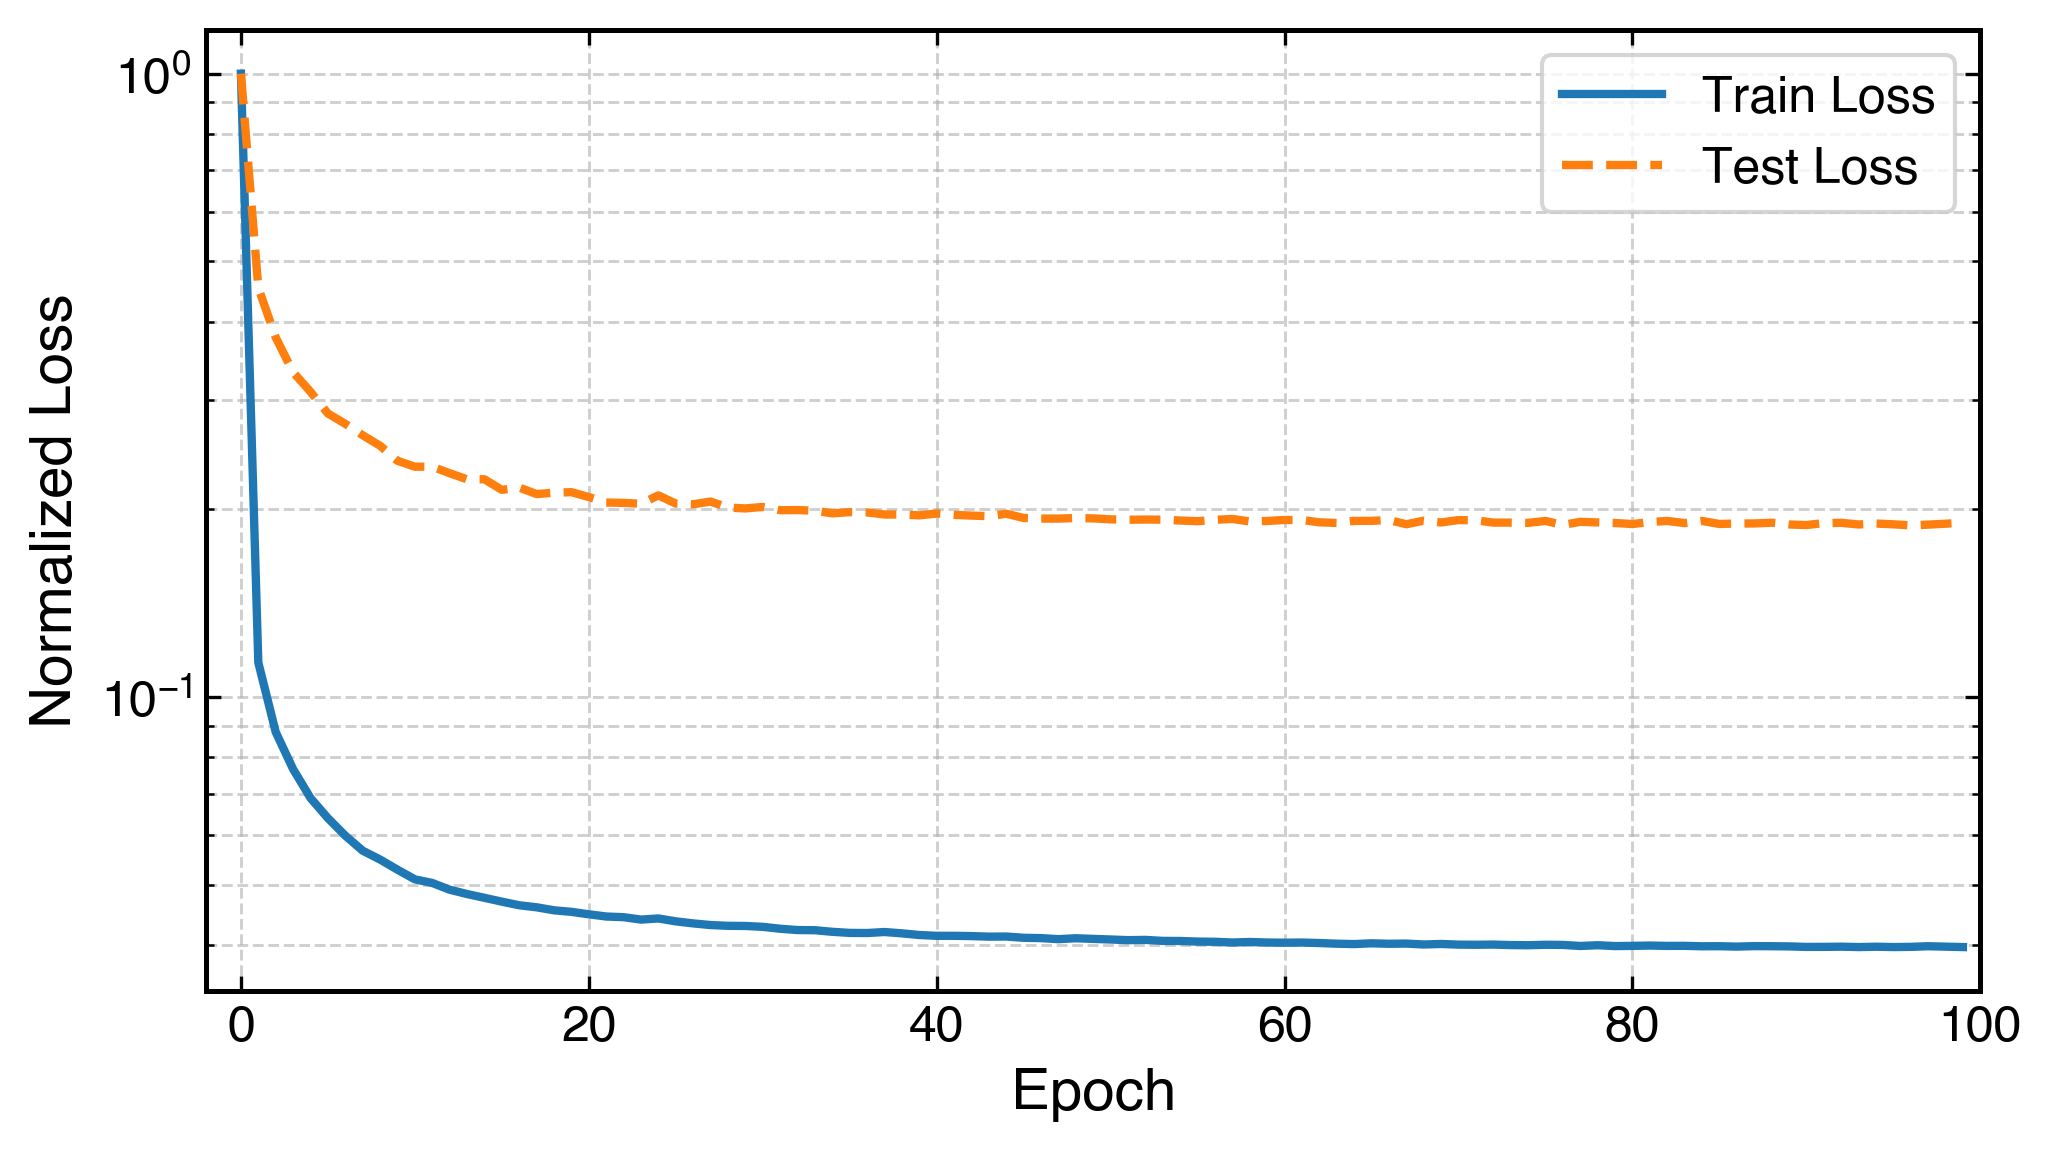

In [5]:
plt.rcParams.update({
    "font.size": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True
})

fig, ax = plt.subplots(figsize=(7, 4), dpi=300)

# Normalize by the first epoch
train_norm = train_losses / train_losses[0]
test_norm  = test_losses / test_losses[0]

# Plot
ax.plot(train_norm, label="Train Loss", lw=2.0, color="tab:blue")
ax.plot(test_norm,  label="Test Loss",  lw=2.0, color="tab:orange", linestyle="--")

# Labels and scales
ax.set_xlabel("Epoch", fontsize=14)
ax.set_ylabel("Normalized Loss", fontsize=14)
ax.set_yscale("log")
ax.set_xlim(-2, len(train_losses))
# Grid and legend
ax.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.6)
ax.legend(fontsize=12, frameon=True)
plt.tight_layout()
plt.savefig(f"figures/prior_vae_loss.png", dpi=300, bbox_inches='tight')
plt.show()


### Load Data

In [6]:
path = Path('/net/vision/scr2/haipeng/FWI-HMC/')

train_data = np.load(path/'model2D/sa_prior_time25_samples_64x64_train.npy')
val_data   = np.load(path/'model2D/sa_prior_time25_samples_64x64_val.npy')
train_data = torch.tensor(train_data).float()
val_data   = torch.tensor(val_data).float()

print(f"Train data shape: {train_data.shape}, min: {train_data.min()}, max: {train_data.max()}")
print(f"Val   data shape: {val_data.shape},   min: {val_data.min()},   max: {val_data.max()}")

Train data shape: torch.Size([7800, 1, 64, 64]), min: 0.0, max: 0.5573965311050415
Val   data shape: torch.Size([200, 1, 64, 64]),   min: 0.0,   max: 0.5320130586624146


In [7]:
dx, dz = 5.0, 5.0 
nz_res, nx_res = 15, 179
res_x = np.arange(nx_res) * dx + (200-90) * dx
res_z = np.arange(nz_res) * dx + 260 * dx

extent=[res_x[0]/1000, res_x[-1]/1000, res_z[-1]/1000, res_z[0]/1000]

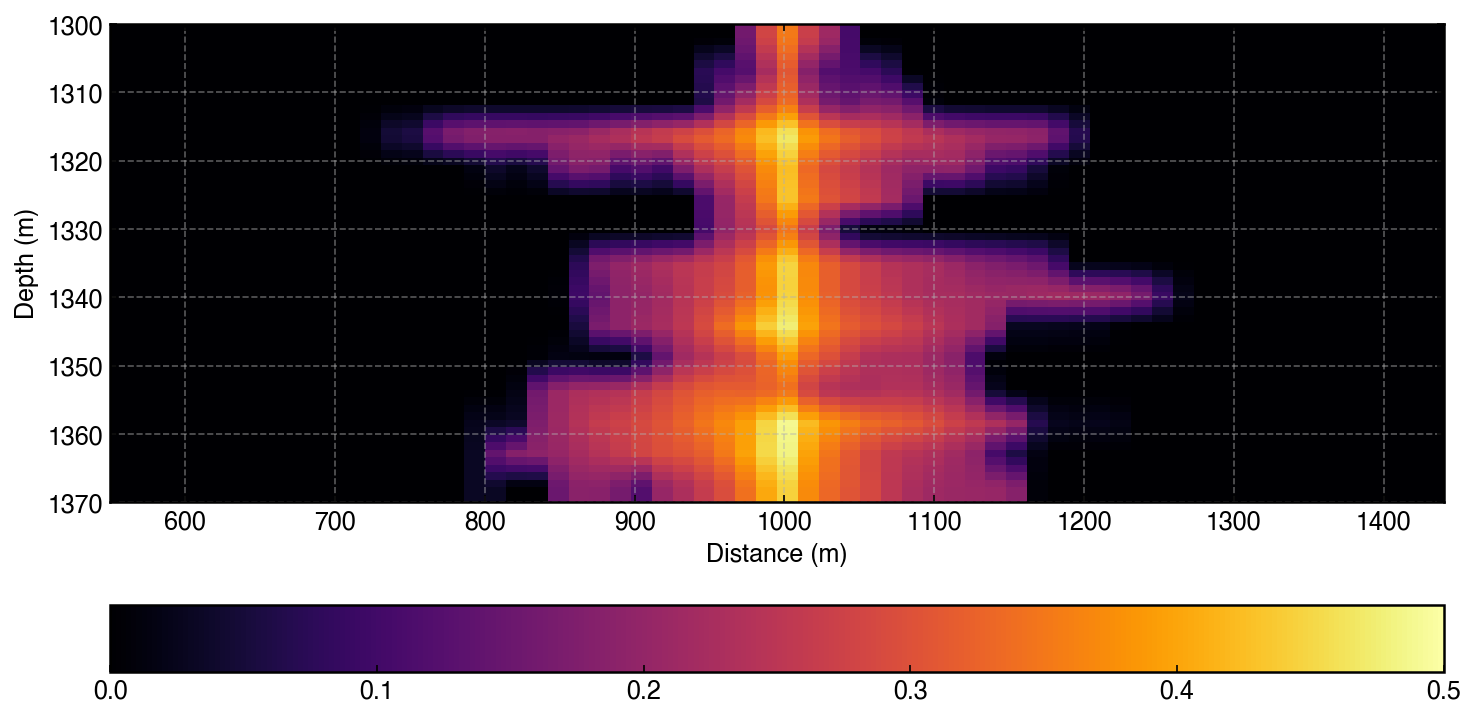

In [8]:
plot_2d(res_x, res_z, val_data[10].squeeze(), vmin=0, vmax=0.5, cmap='inferno')

### Evaluate Models

In [9]:
# Model
in_channels = 1
latent_dim = 64
kld_weight = 0.000015
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reload the model
checkpoint_path = path / f"VAE/vae_latent_dim{latent_dim}_kld_weight{kld_weight}.pth"
model = VanillaVAE(in_channels=in_channels, latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()
None

### Latent Space Interpolation (Smoothness & Continuity)

In [10]:
# set the seed for reproducibility
torch.manual_seed(111)
num_samples = 6
z = torch.randn(num_samples, model.latent_dim).to(device)

z1, z2 = z[0], z[1]
z3, z4 = z[2], z[3]
z5, z6 = z[4], z[5]

In [11]:
ntest = 6
sigma   = np.linspace(0.0, 1.0, ntest)  # Range of sigma values for interpolation
z_test1 = torch.stack([z1 * (1 - s) + z2 * s for s in sigma]).to(device)
z_test2 = torch.stack([z3 * (1 - s) + z4 * s for s in sigma]).to(device)
z_test3 = torch.stack([z5 * (1 - s) + z6 * s for s in sigma]).to(device)

with torch.no_grad():
    generated_test1 = model.decode(z_test1).cpu().numpy().squeeze()
    generated_test2 = model.decode(z_test2).cpu().numpy().squeeze()
    generated_test3 = model.decode(z_test3).cpu().numpy().squeeze()

In [12]:
def compute_ssim(generated):
    
    ntest = generated.shape[0]
    ssim_values = np.zeros((ntest, ntest))

    for i in range(ntest):
        for j in range(ntest):
            img1 = generated[i]
            img2 = generated[j]
            img1 = (img1 - img1.min()) / (img1.max() - img1.min())
            img2 = (img2 - img2.min()) / (img2.max() - img2.min())

            ssim_score, _ = ssim(img1, img2, data_range=1.0, full=True)
            
            ssim_values[i, j] = ssim_score
            
    return ssim_values

In [13]:
ssim_values_test1 = compute_ssim(generated_test1)
ssim_values_test2 = compute_ssim(generated_test2)
ssim_values_test3 = compute_ssim(generated_test3)

ssim_neib1 = np.diag(ssim_values_test1, k=1)
ssim_neib2 = np.diag(ssim_values_test2, k=1)
ssim_neib3 = np.diag(ssim_values_test3, k=1)

In [14]:
configure_plot_settings()

fontsize = 15

plt.rcParams.update({
    "font.size": fontsize,
    "axes.labelsize": fontsize,
    "axes.titlesize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

/tmp/ipykernel_8176/4289651555.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


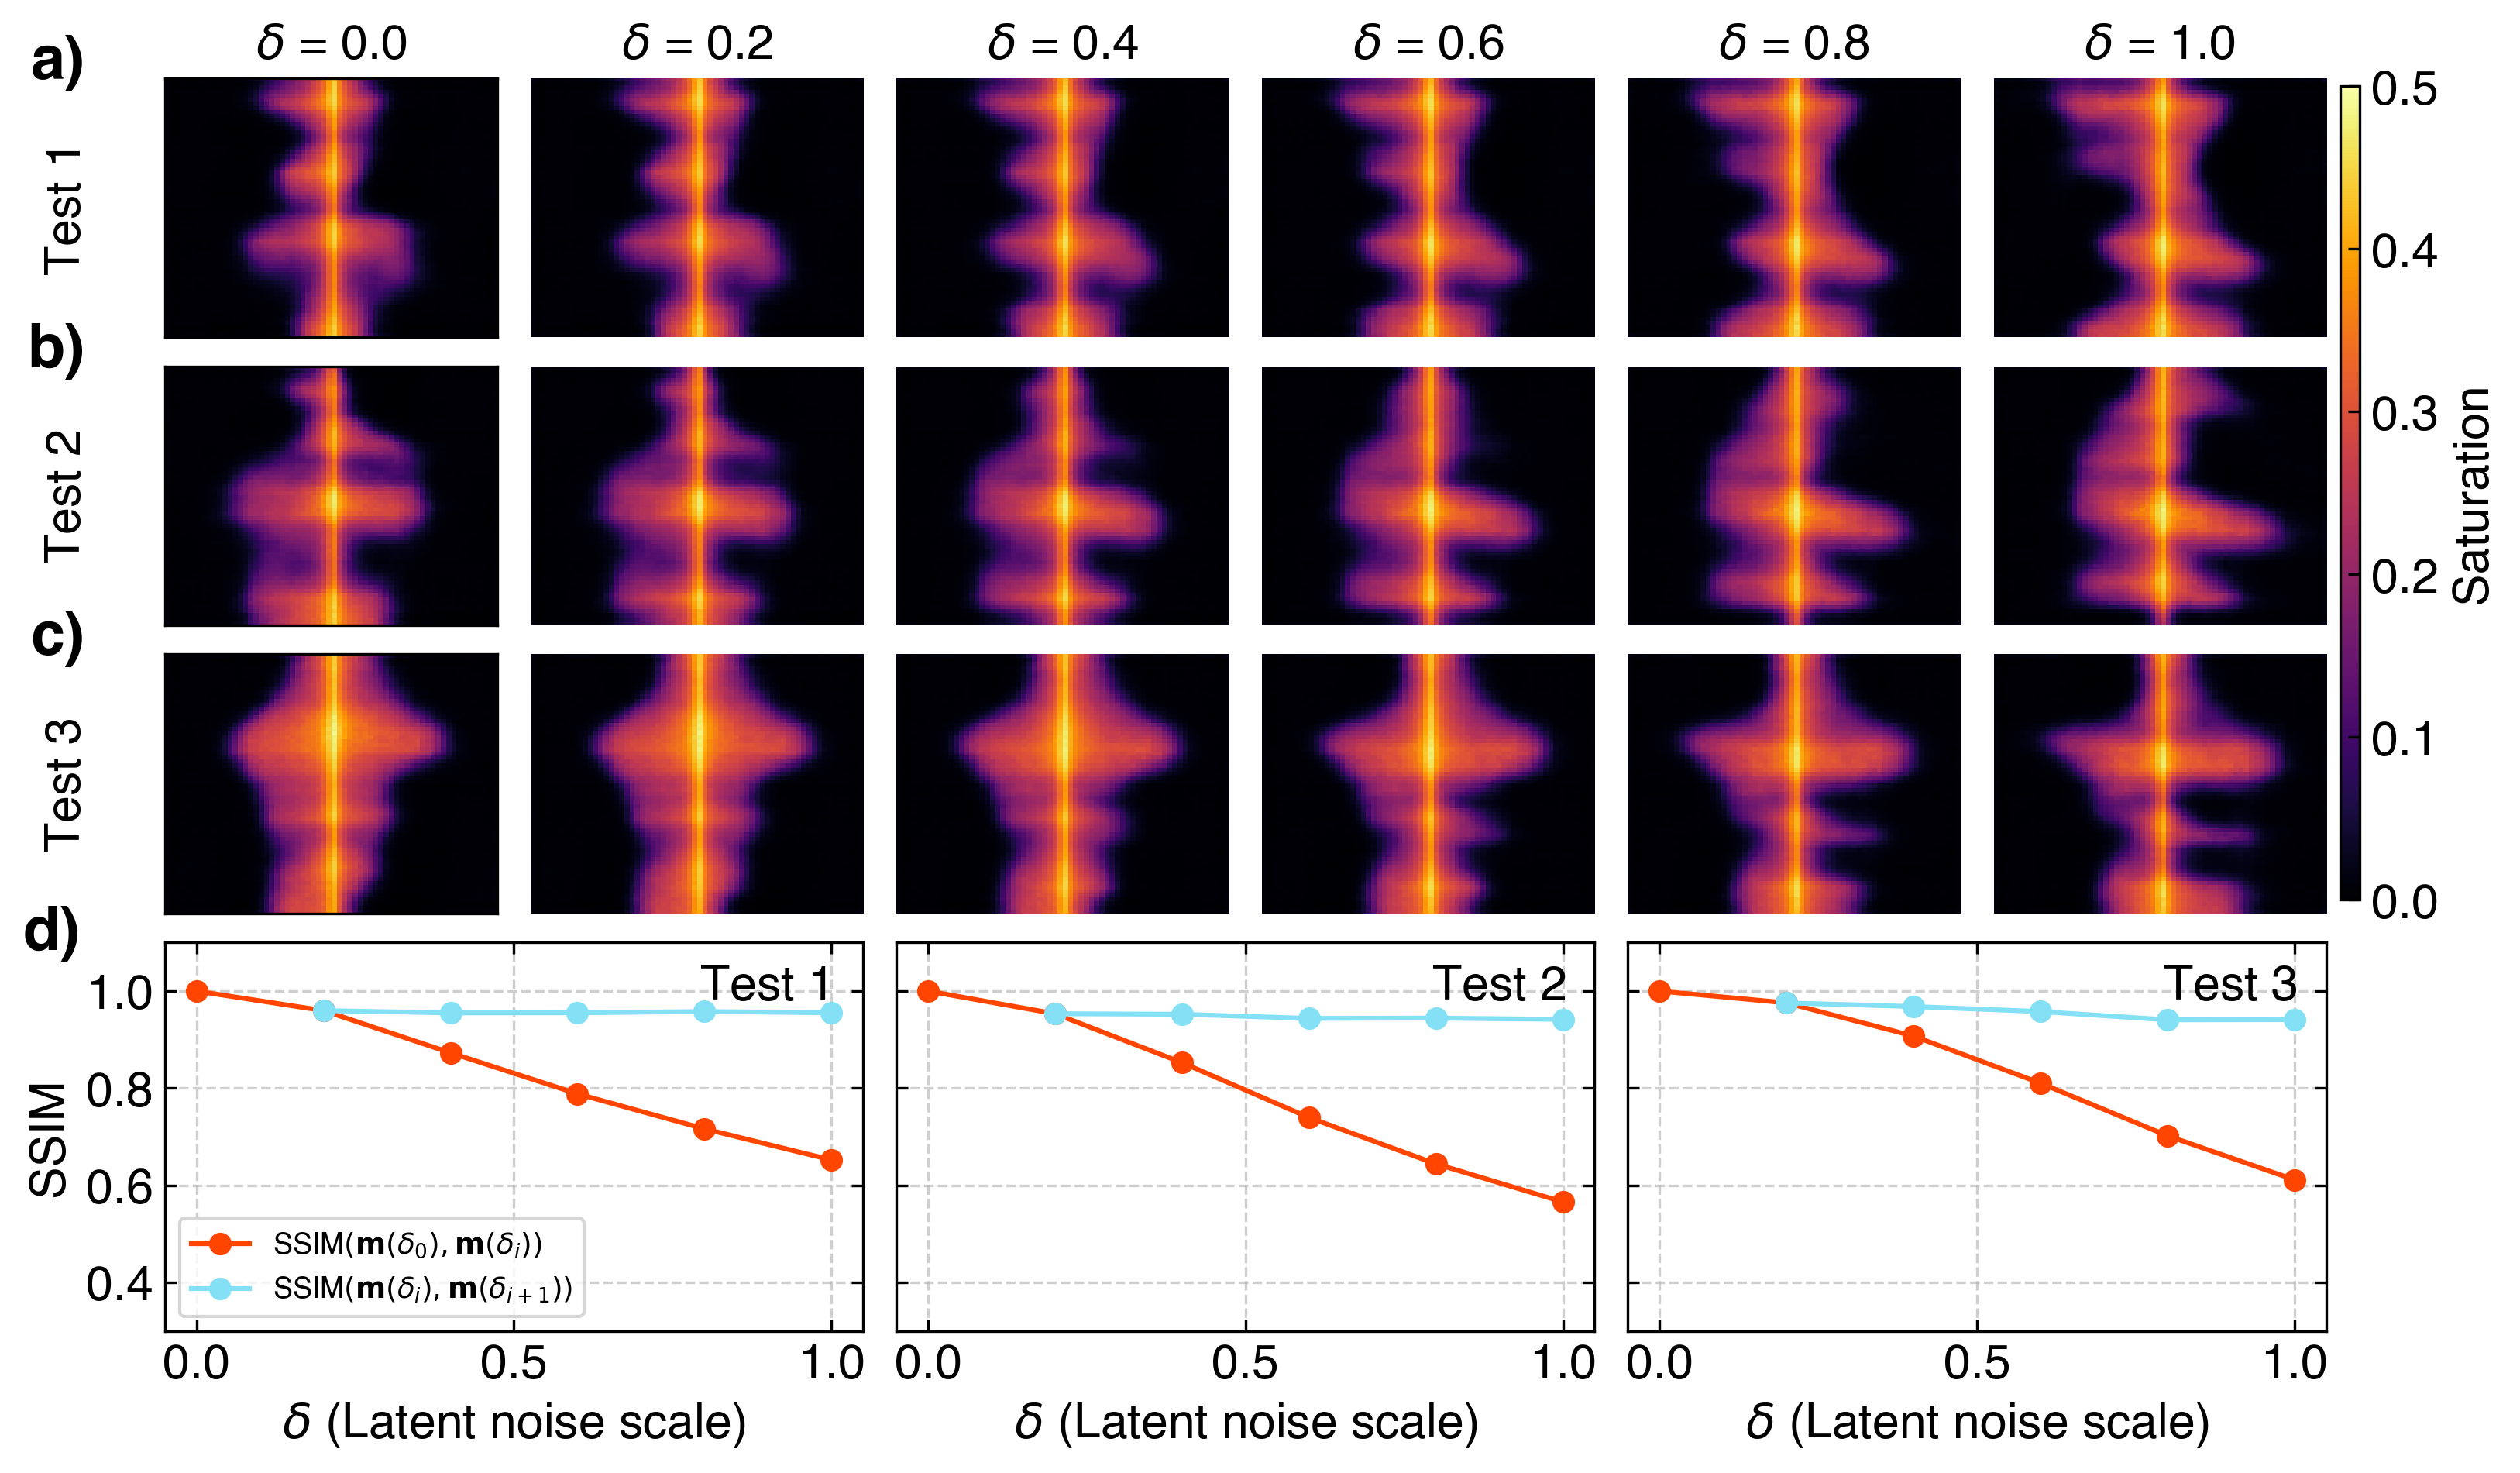

In [15]:
cols = ntest
rows = 4 
fig = plt.figure(figsize=(12, 7), dpi=300)
gs = gridspec.GridSpec(rows, cols, figure=fig, height_ratios=[1, 1, 1, 1.5], hspace=0.1, wspace=0.1)
cmap = 'inferno'
im_axes = []
labels = ['a)', 'b)', 'c)', 'd)']

row_labels = ['Test 1', 'Test 2', 'Test 3']
generated_tests = [generated_test1, generated_test2, generated_test3]

# Plot rows of generated images and add row labels
for row in range(3):
    for col in range(cols):
        ax = fig.add_subplot(gs[row, col])
        im = ax.imshow(generated_tests[row][col], cmap=cmap, aspect='auto', vmin=0, vmax=0.5)
        ax.axis('off')
        if row == 0:
            ax.set_title(f'$\delta$ = {sigma[col]:.1f}', fontsize=fontsize)
        im_axes.append(im)
    
        # Add subplot label (a), b), c)) to the first column
        if col == 0:
            ax.text(-0.24, 0.95, labels[row], transform=ax.transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")

    # Add row label on the left
    ax_label = fig.add_subplot(gs[row, 0])
    ax_label.set_ylabel(row_labels[row], fontsize=fontsize, rotation=90, labelpad=30, va='center')
    ax_label.set_xticks([])
    ax_label.set_yticks([])
    ax_label.patch.set_alpha(0)  # Transparent background


# Shared colorbar
cbar_ax = fig.add_axes([0.905, 0.375, 0.007, 0.5])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax)
cbar.set_label('Saturation', fontsize=fontsize)
# 0, 0.1, 0.2, 0.3, 0.4
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cbar.ax.tick_params(labelsize=fontsize)

# Row 4: SSIM plots
plot_labels = [
    (r'SSIM$(\mathbf{m}(\delta_0), \mathbf{m}(\delta_i))$', 
     r'SSIM$(\mathbf{m}(\delta_i), \mathbf{m}(\delta_{i+1}))$', 
     ssim_values_test1[0], ssim_neib1, 'Test 1'),

    (r'SSIM$(\mathbf{m}(\delta_0), \mathbf{m}(\delta_i))$', 
     r'SSIM$(\mathbf{m}(\delta_i), \mathbf{m}(\delta_{i+1}))$', 
     ssim_values_test2[0], ssim_neib2, 'Test 2'),

    (r'SSIM$(\mathbf{m}(\delta_0), \mathbf{m}(\delta_i))$', 
     r'SSIM$(\mathbf{m}(\delta_i), \mathbf{m}(\delta_{i+1}))$', 
     ssim_values_test3[0], ssim_neib3, 'Test 3'),
]

for i, (label1, label2, val, neib, title) in enumerate(plot_labels):
    ax = fig.add_subplot(gs[3, 2 * i:2 * (i + 1)])
    if i == 0:
        ax.plot(sigma, val, 'o-', label=label1, color='orangered')
        ax.plot(sigma[1:], neib, 'o-', label=label2, color='#84e0f4')
        ax.legend(fontsize=9, loc='lower left', frameon=True)
    else:
        ax.plot(sigma, val, 'o-', color='orangered')
        ax.plot(sigma[1:], neib, 'o-', color='#84e0f4')    # add text annotation
    ax.text(0.9, 0.96, title, fontsize=fontsize, ha='center', va='bottom')
    ax.set_xlabel('$\delta$ (Latent noise scale)', fontsize=fontsize)
    if i==0:
        ax.set_ylabel('SSIM', fontsize=fontsize)
    else:
        ax.set_yticklabels([])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='both', labelsize=fontsize)
    ax.set_ylim([0.3, 1.1])
    ax.set_xlim([sigma[0]-0.05, sigma[-1]+0.05])

# Add "d)" to the first SSIM subplot (row 3, col 0)
fig.axes[-len(plot_labels)].text(-0.12, 0.95, "d)", transform=fig.axes[-len(plot_labels)].transAxes, fontsize=19, fontweight="bold", va="bottom", ha="right")
plt.tight_layout()
plt.savefig(f"figures/prior_latent_continuity.png", dpi=300, bbox_inches='tight')
plt.show()

### Random Generation

In [31]:
torch.manual_seed(121)
num_samples = 6*8
z = torch.randn(num_samples, model.latent_dim).to(device)

with torch.no_grad():
    CO2_gene = model.decode(z).cpu().numpy().squeeze()

/tmp/ipykernel_27192/1285543566.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])  # leave room for colorbar


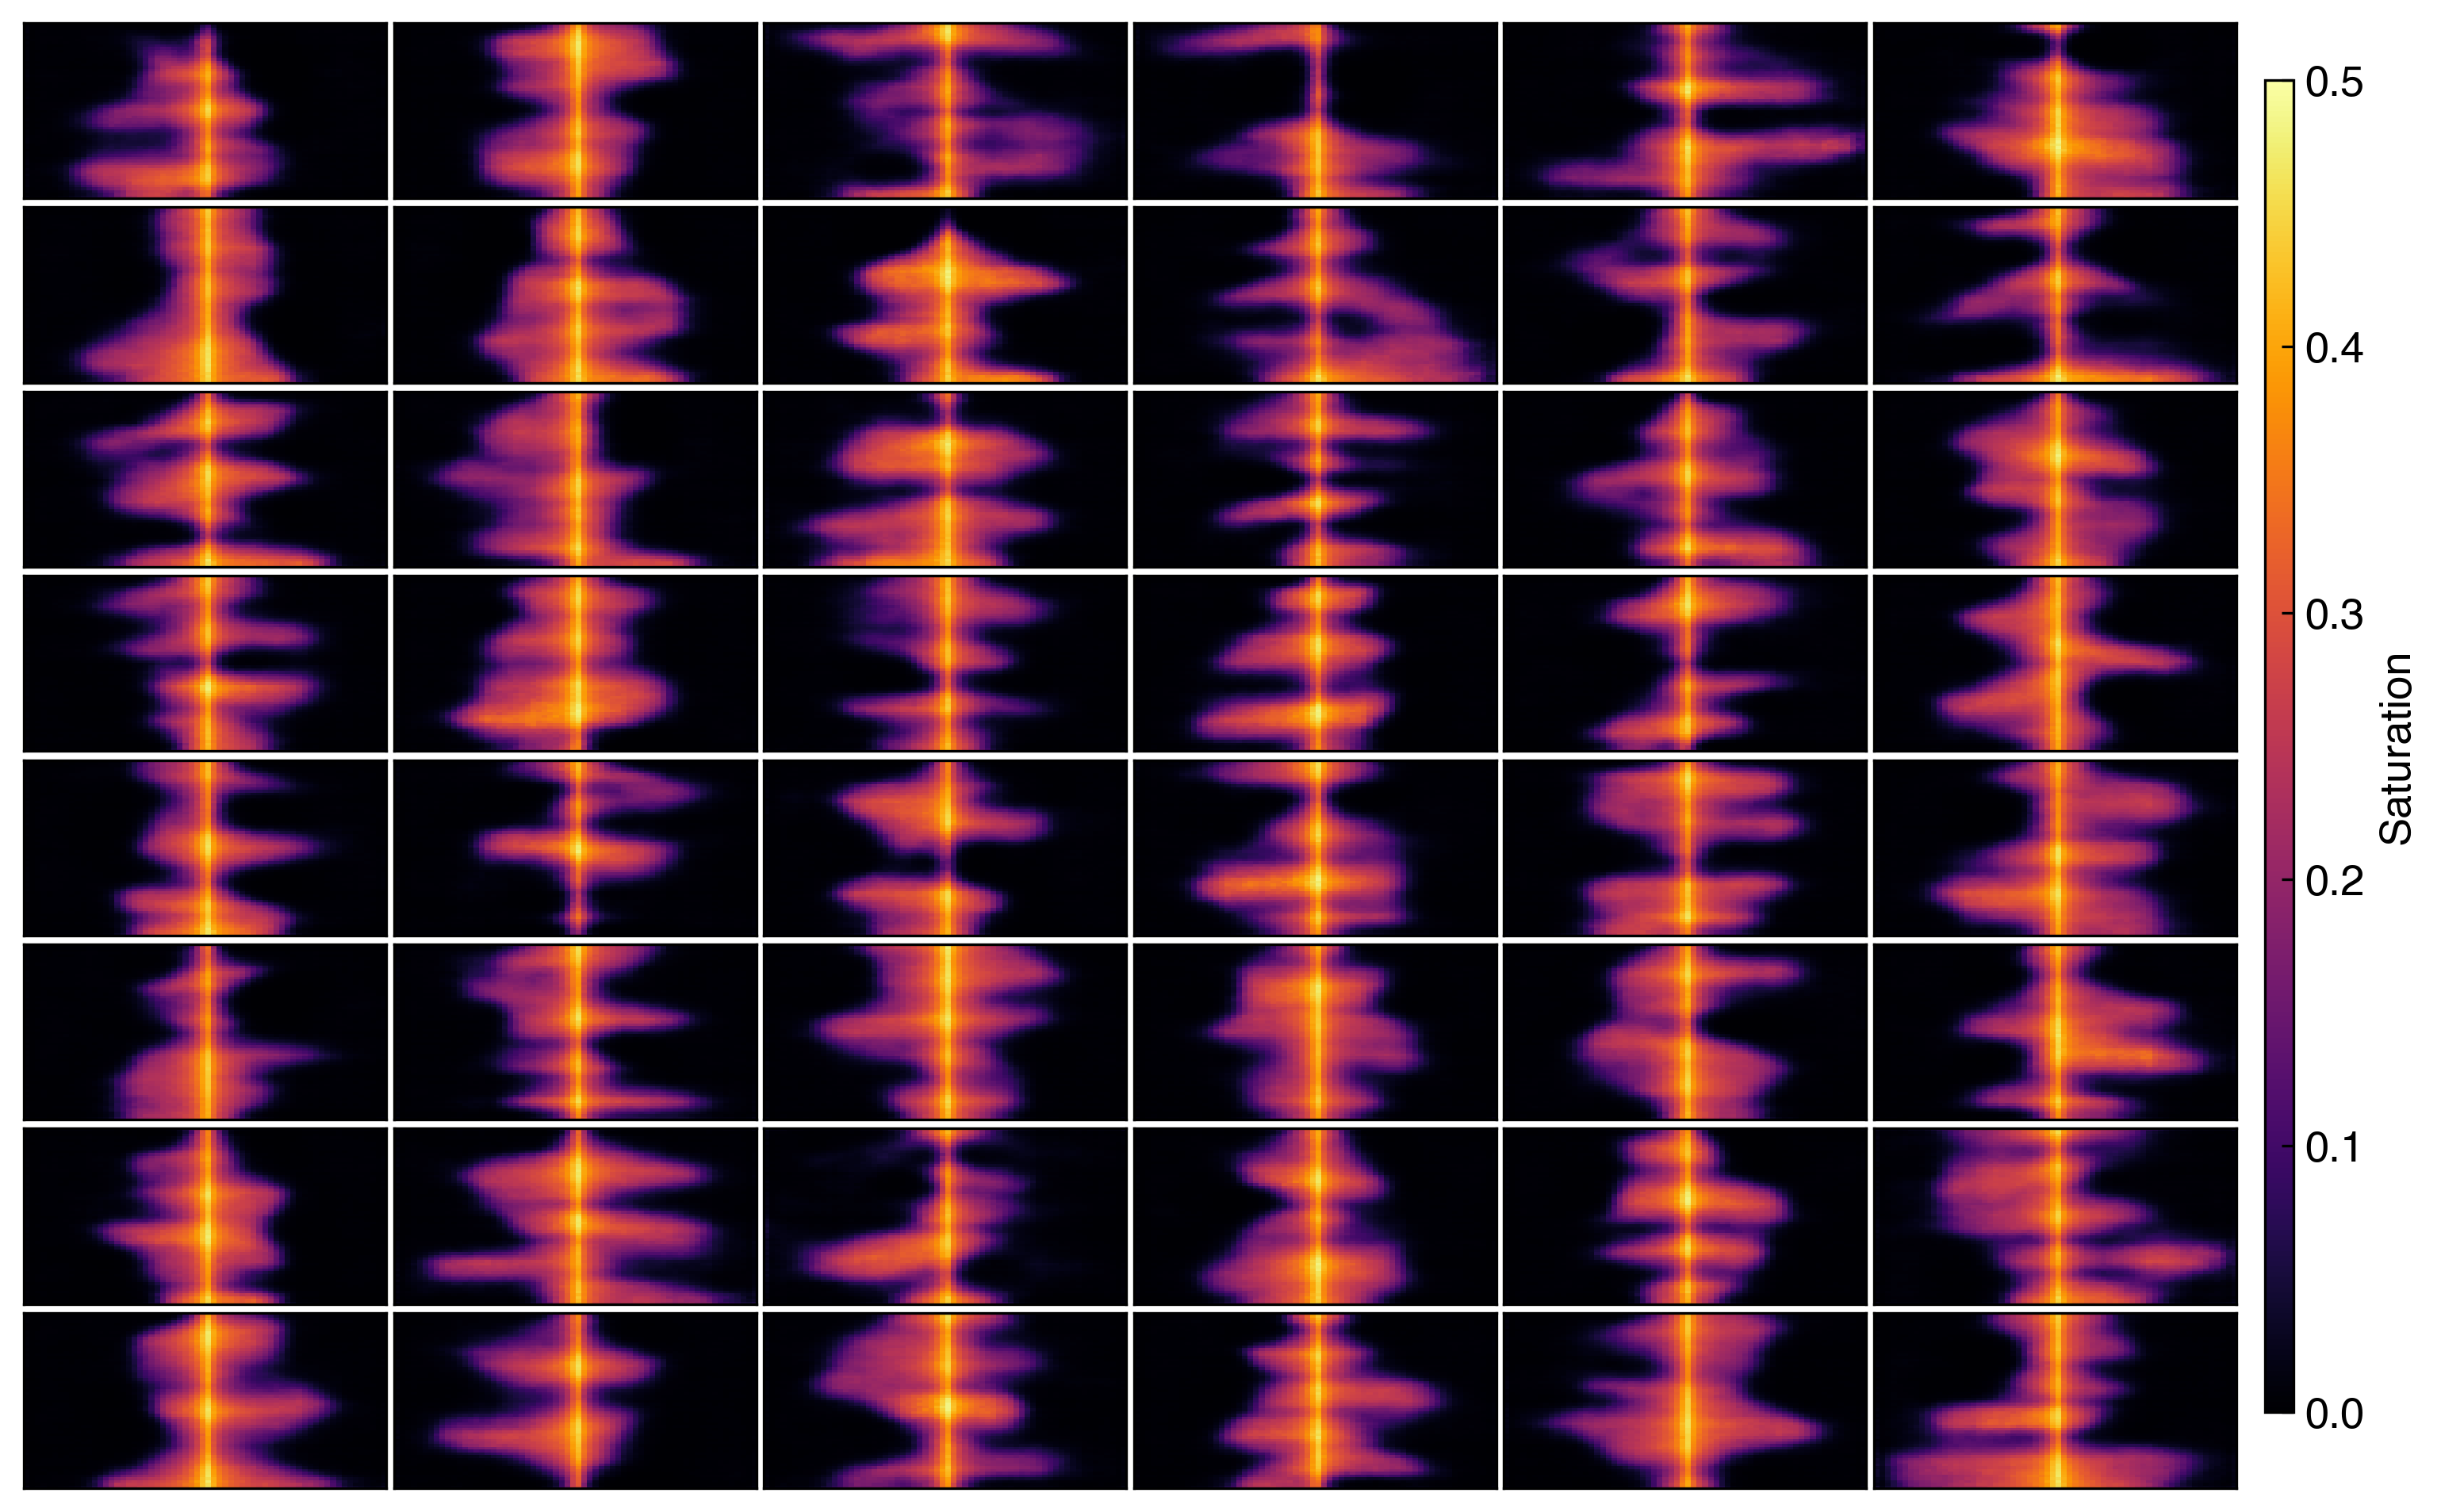

In [32]:
fig = plt.figure(figsize=(12, 8), dpi=300)

gs = gridspec.GridSpec(8, 6, figure=fig, hspace=0.05, wspace=0.02)
cmap = 'inferno'
im_axes = []

nrows, ncols = 8, 6

# Plot grid of generated CO2 images
for i, co2 in enumerate(CO2_gene):
    row = i // ncols
    col = i % ncols

    ax = fig.add_subplot(gs[row, col])
    im = ax.imshow(co2, cmap=cmap, aspect='auto',  vmin=0, vmax=0.5, extent=extent)

    # Turn off axis labels for all subplots except lower left
    # if row == nrows - 1 and col == 0:
    #     ax.set_xlabel('Distance (m)', fontsize=13)
    #     ax.set_ylabel('Depth (m)', fontsize=13)
    #     ax.tick_params(labelsize=13)        
    # else:
    #     ax.set_xticks([])
    #     ax.set_yticks([])
    ax.set_xticks([])
    ax.set_yticks([])

    im_axes.append(im)

# Add shared colorbar
cbar_ax = fig.add_axes([0.91, 0.15, 0.010, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax)
cbar.set_label('Saturation', fontsize=13)
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cbar.ax.tick_params(labelsize=13)

plt.tight_layout(rect=[0, 0, 0.91, 1])  # leave room for colorbar
plt.savefig("figures/prior_random_generation.png", dpi=300, bbox_inches='tight')
plt.show()

### Reconstruction (use validation dataset)

In [33]:
torch.manual_seed(2222)
num_samples = 3*5
# generate a random int number between 0 and 8002
idx = torch.randint(0, val_data.shape[0], (num_samples,))
val_data_select = val_data[idx]
val_data_select.shape

torch.Size([15, 1, 64, 64])

In [34]:
with torch.no_grad():
    val_data_recon = model.generate(val_data_select.to(device))

/tmp/ipykernel_27192/805993714.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])  # Leave room for colorbar


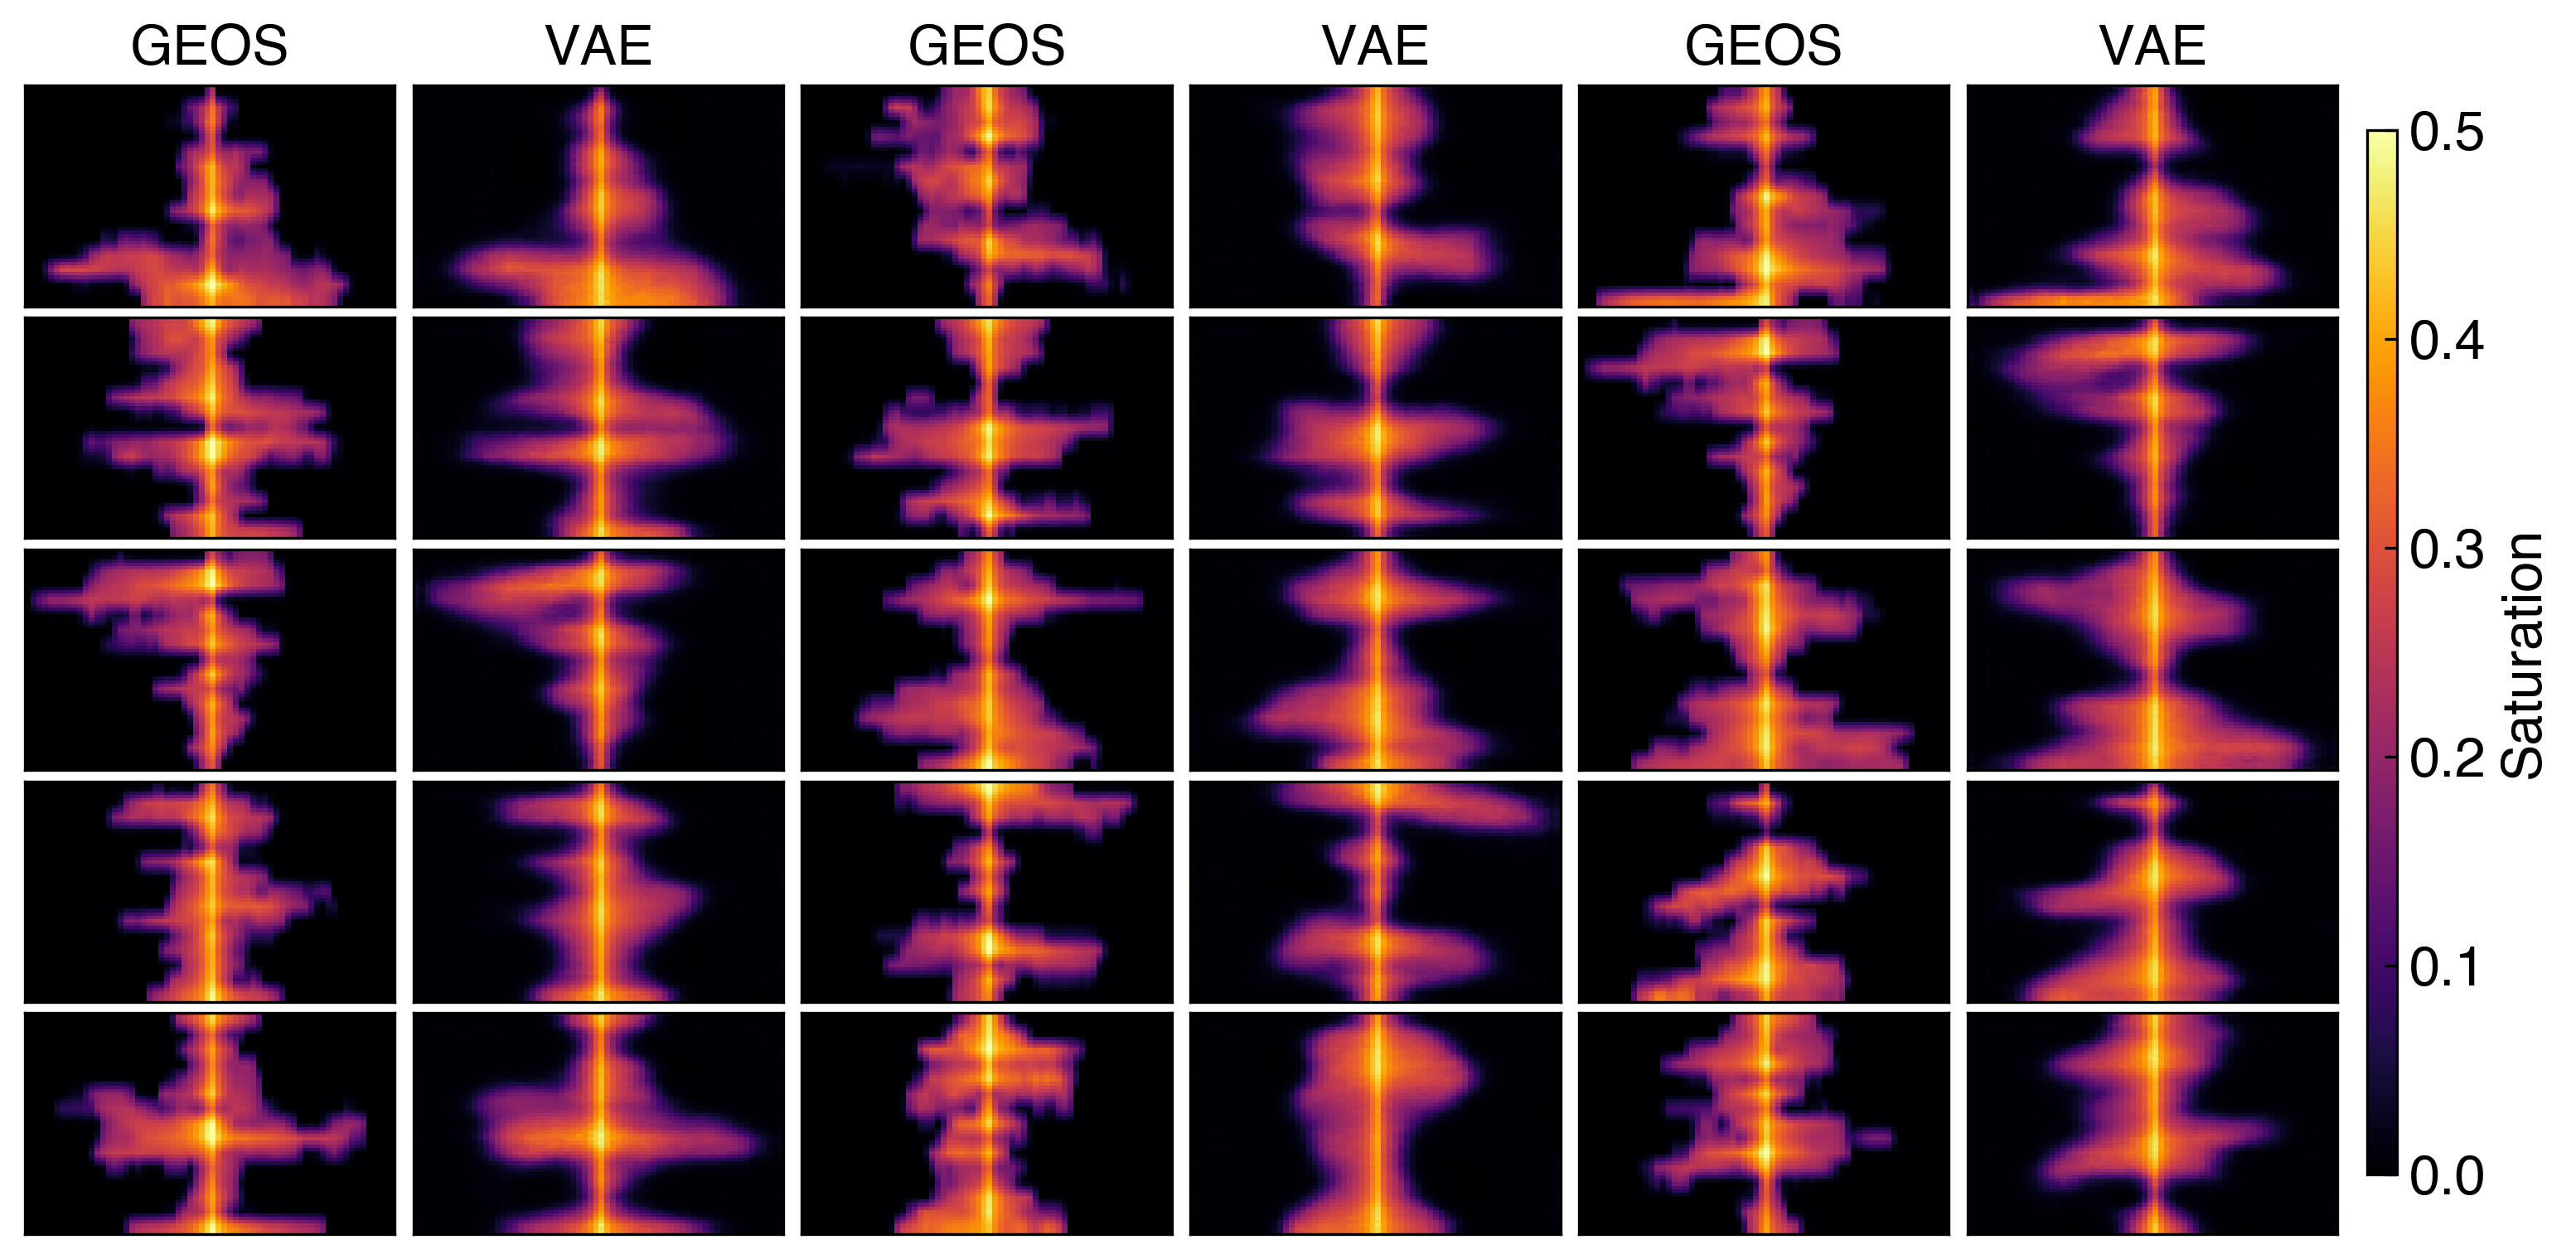

In [35]:
fig = plt.figure(figsize=(12, 6), dpi=300)
gs = gridspec.GridSpec(5, 6, figure=fig, hspace=0.05, wspace=0.05)

fontsize = 16
cmap = 'inferno'
im_axes = []

nrows, ncols = 5, 6  # 6 columns = 3 original + 3 recon per row
num_pairs = (nrows * ncols) // 2  # number of original+recon pairs to plot

for i in range(num_pairs):
    row = i // (ncols // 2)
    pair_col = i % (ncols // 2)

    # Original image at even column (0, 2, 4)
    ax_orig = fig.add_subplot(gs[row, 2 * pair_col])
    im = ax_orig.imshow(val_data_select[i].cpu().numpy().squeeze(), cmap=cmap, aspect='auto', vmin=0, vmax=0.5, extent=extent)
    im_axes.append(im)
    if row==0:
        ax_orig.set_title(f"GEOS", fontsize=fontsize)
    # if row == nrows - 1 and 2 * pair_col == 0:
    #     ax_orig.set_xlabel('Distance (km)', fontsize=fontsize)
    #     ax_orig.set_ylabel('Depth (km)', fontsize=fontsize)
    #     ax_orig.set_xticks(np.arange(0.6, res_x[-1]/1000+0.3, 0.3))
    #     ax_orig.set_yticks(np.arange(res_z[0]/1000, res_z[-1]/1000, 0.02))
    #     ax_orig.set_xlim(res_x[0]/1000, res_x[-1]/1000)
    #     ax_orig.set_ylim(res_z[-1]/1000, res_z[0]/1000)
    #     ax_orig.tick_params(labelsize=fontsize)
    # else:
    #     ax_orig.set_xticks([])
    #     ax_orig.set_yticks([])
    
    ax_orig.set_xticks([])
    ax_orig.set_yticks([])

    # Reconstructed image at odd column (1, 3, 5)
    ax_recon = fig.add_subplot(gs[row, 2 * pair_col + 1])
    im = ax_recon.imshow(val_data_recon[i].cpu().numpy().squeeze(), cmap=cmap, aspect='auto', vmin=0, vmax=0.5, extent=extent)
    im_axes.append(im)
    if row==0:
        ax_recon.set_title(f"VAE", fontsize=fontsize)

    ax_recon.set_xticks([])
    ax_recon.set_yticks([])

# Shared colorbar
cbar_ax = fig.add_axes([0.91, 0.15, 0.010, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(im_axes[0], cax=cbar_ax)
cbar.set_ticks([0, 0.1, 0.2, 0.3, 0.4, 0.5])
cbar.set_label('Saturation', fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize)

plt.tight_layout(rect=[0, 0, 0.91, 1])  # Leave room for colorbar
plt.savefig("figures/prior_reconstruction.png", dpi=300, bbox_inches='tight')
plt.show()

### Statistics of Generated Samples

In [36]:
torch.manual_seed(666)
num_samples = train_data.shape[0]
z = torch.randn(num_samples, model.latent_dim).to(device)

with torch.no_grad():
    CO2_gene = model.decode(z).cpu().numpy().squeeze()

In [37]:
CO2_true = train_data.cpu().numpy().squeeze()

In [38]:
# Histogram Comparison
p10_true = np.percentile(CO2_true, 10, axis=0)
p50_true = np.percentile(CO2_true, 50, axis=0)
p90_true = np.percentile(CO2_true, 90, axis=0)

p10_gene = np.percentile(CO2_gene, 10, axis=0)
p50_gene = np.percentile(CO2_gene, 50, axis=0)
p90_gene = np.percentile(CO2_gene, 90, axis=0)

/tmp/ipykernel_27192/1567620356.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


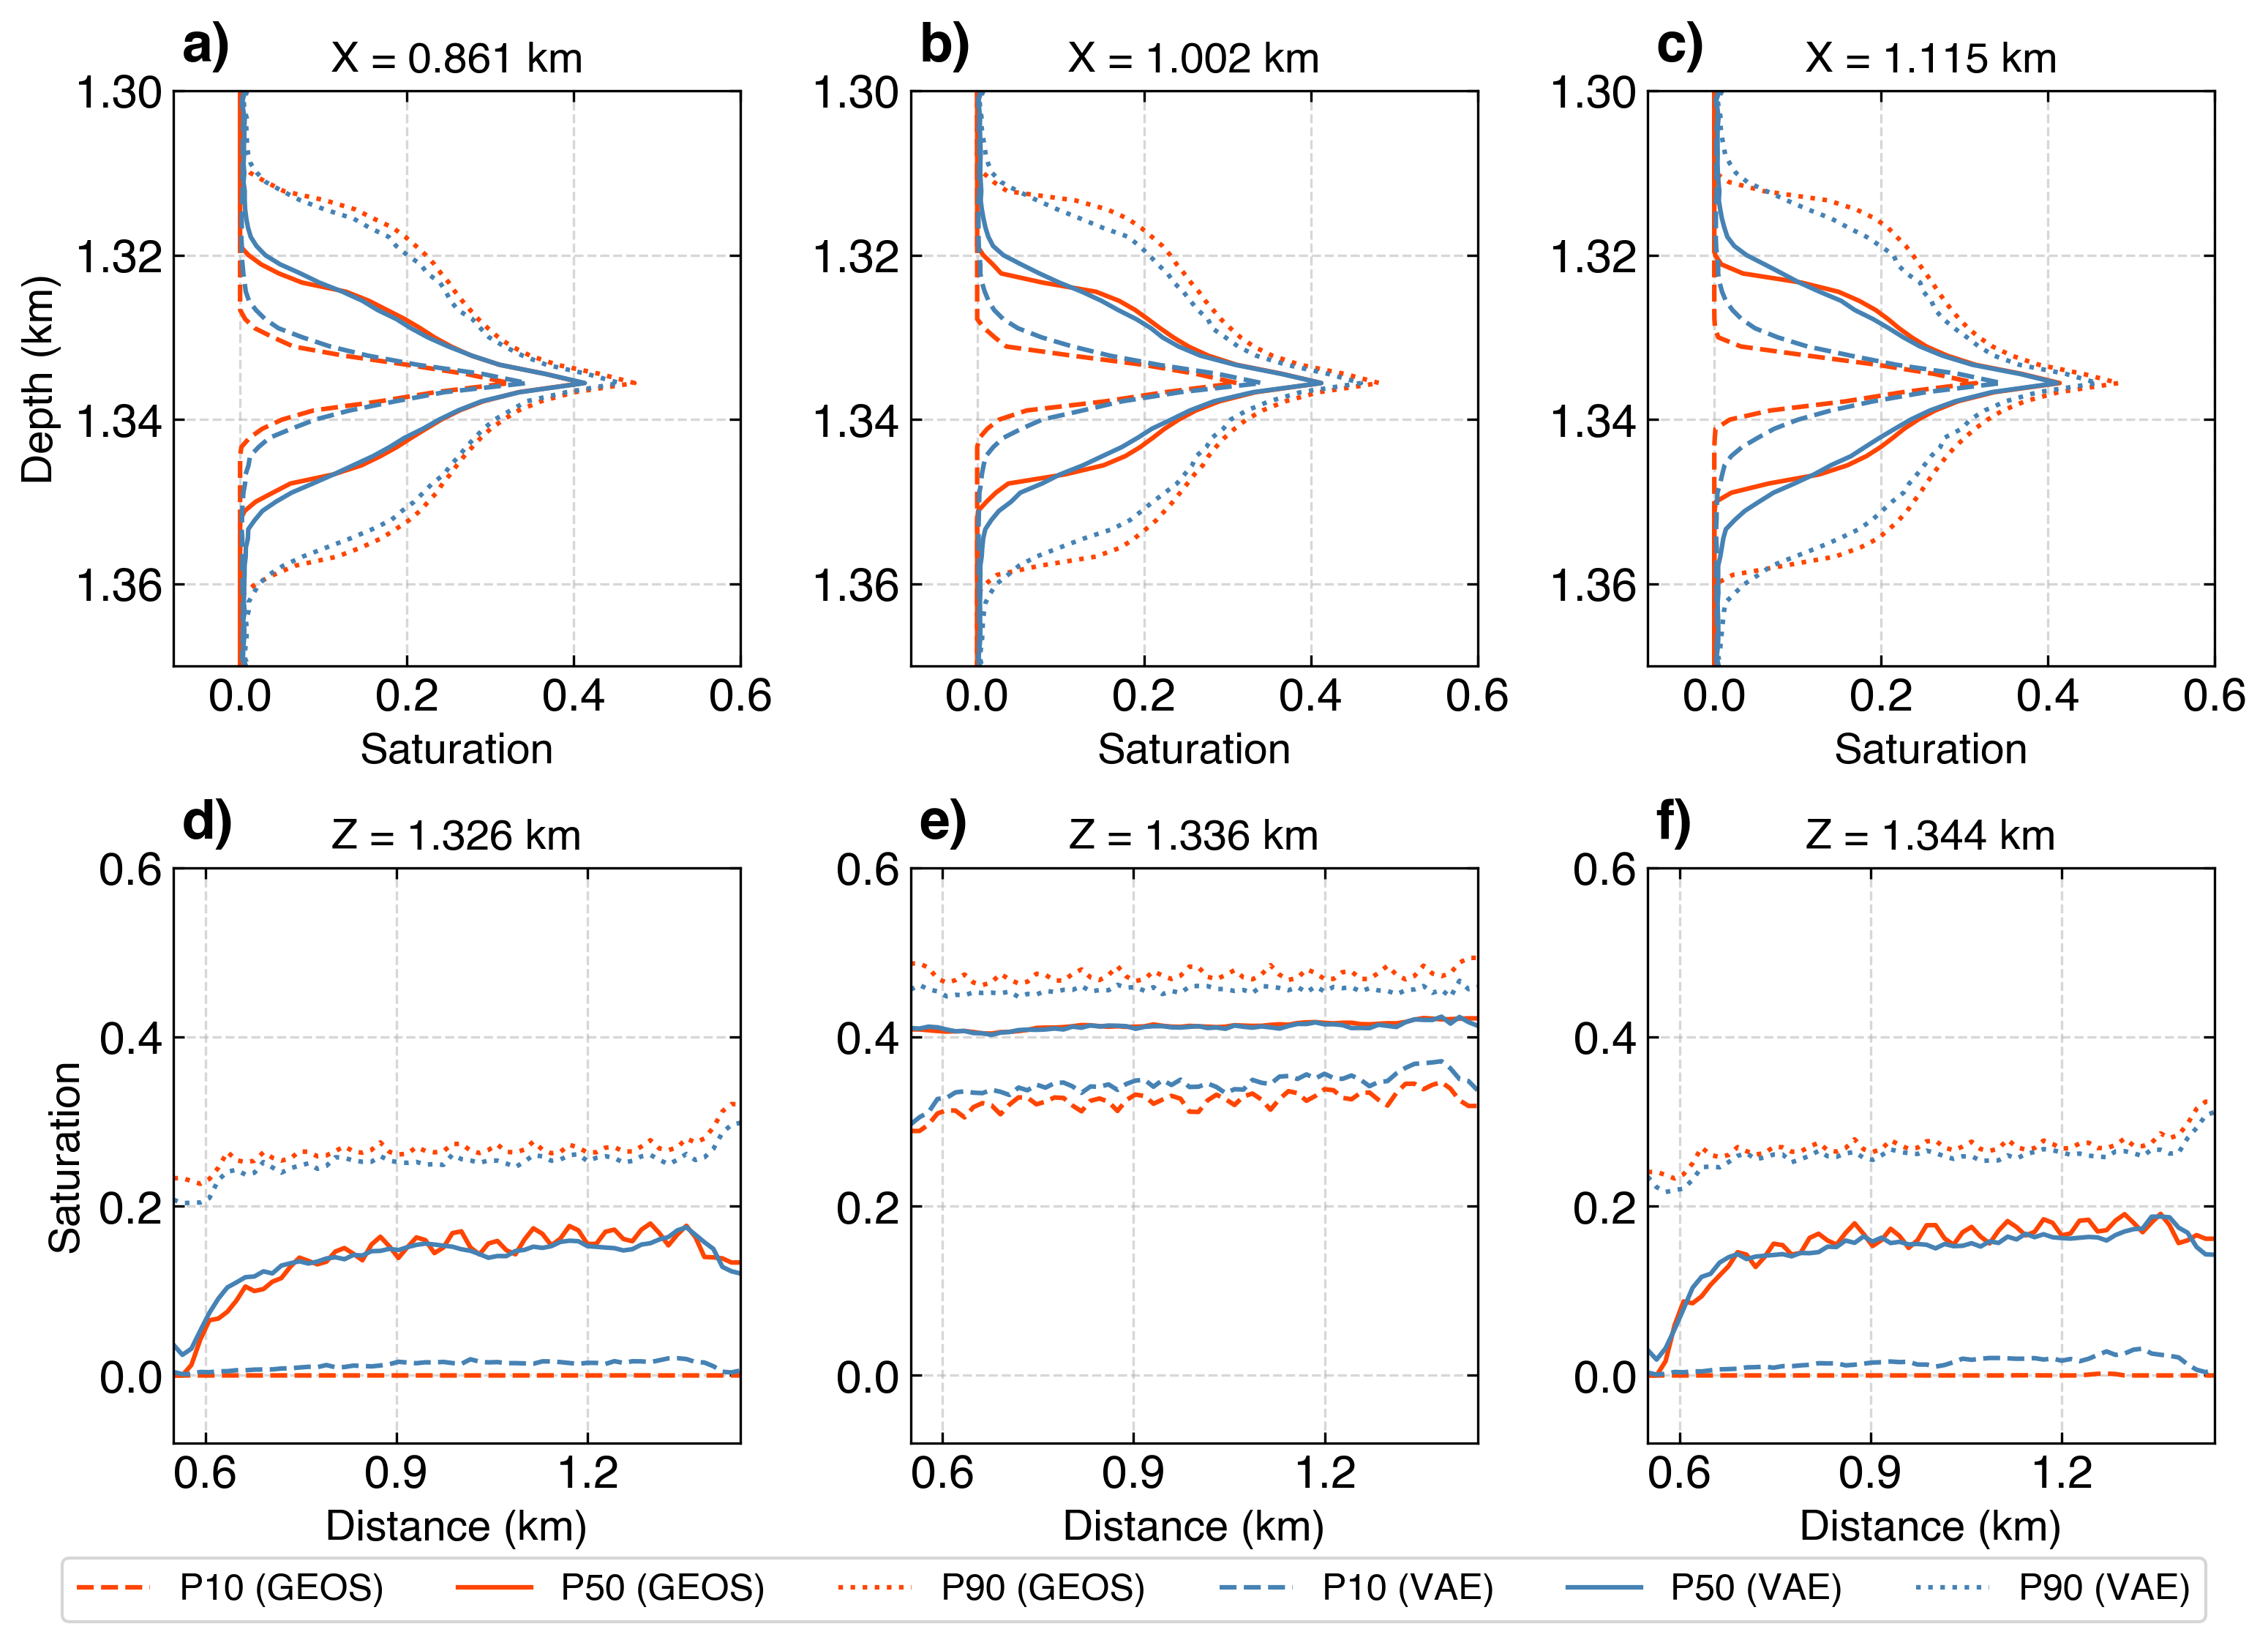

In [39]:
x = np.linspace(res_x.min(), res_x.max(), 64) / 1000  # in km
z = np.linspace(res_z.min(), res_z.max(), 64) / 1000  # in km

# Indices to plot
loc_x = [22, 32, 40]  # lateral positions for z-profile plots (top row)
loc_z = [23, 32, 40]  # depth levels for x-profile plots (bottom row)

nrows, ncols = 2, 3
fig = plt.figure(figsize=(12, 8), dpi=300)
gs = gridspec.GridSpec(nrows, ncols, figure=fig, hspace=0.35, wspace=0.3)

colors_true = 'orangered'
colors_gene = 'steelblue'

# Top row: vertical profiles at different X
labels = ['a)', 'b)', 'c)']
for i, lx in enumerate(loc_x):
    ax = fig.add_subplot(gs[0, i])
    
    ax.plot(p10_true[lx], z, label='P10 (GEOS)', color=colors_true, linestyle='--', linewidth=1.5)
    ax.plot(p50_true[lx], z, label='P50 (GEOS)', color=colors_true, linestyle='-', linewidth=1.5)
    ax.plot(p90_true[lx], z, label='P90 (GEOS)', color=colors_true, linestyle=':', linewidth=1.5)
    
    ax.plot(p10_gene[lx], z, label='P10 (VAE)', color=colors_gene, linestyle='--', linewidth=1.5)
    ax.plot(p50_gene[lx], z, label='P50 (VAE)', color=colors_gene, linestyle='-', linewidth=1.5)
    ax.plot(p90_gene[lx], z, label='P90 (VAE)', color=colors_gene, linestyle=':', linewidth=1.5)

    ax.set_title(f'X = {x[lx]:.3f} km', fontsize=14)
    ax.set_xlabel('Saturation', fontsize=14)
    ax.set_yticks(np.arange(res_z[0]/1000, res_z[-1]/1000, 0.02))
    ax.set_xlim(-0.08, 0.6)
    ax.set_ylim(z[-1], z[0])  # make sure depth is increasing downward
    ax.grid(True, linestyle='--', alpha=0.5)

    # add labels
    ax.text(0.015, 1.12, labels[i], transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")

    if i % ncols == 0:
        ax.set_ylabel('Depth (km)', fontsize=14)

# Bottom row: horizontal slices at different Z
labels = ['d)', 'e)', 'f)']
for i, lz in enumerate(loc_z):
    ax = fig.add_subplot(gs[1, i])
    
    ax.plot(x, p10_true[:, lz], label='P10 (GEOS)', color=colors_true, linestyle='--', linewidth=1.5)
    ax.plot(x, p50_true[:, lz], label='P50 (GEOS)', color=colors_true, linestyle='-', linewidth=1.5)
    ax.plot(x, p90_true[:, lz], label='P90 (GEOS)', color=colors_true, linestyle=':', linewidth=1.5)
    
    ax.plot(x, p10_gene[:, lz], label='P10 (VAE)', color=colors_gene, linestyle='--', linewidth=1.5)
    ax.plot(x, p50_gene[:, lz], label='P50 (VAE)', color=colors_gene, linestyle='-', linewidth=1.5)
    ax.plot(x, p90_gene[:, lz], label='P90 (VAE)', color=colors_gene, linestyle=':', linewidth=1.5)

    ax.set_title(f'Z = {z[lz]:.3f} km', fontsize=14)
    ax.set_xlabel('Distance (km)', fontsize=14)
    ax.set_xlim(x[0], x[-1])
    ax.set_xticks(np.arange(0.6, res_x[-1]/1000+0.3, 0.3))
    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(-0.08, 0.6)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.text(0.015, 1.12, labels[i], transform=ax.transAxes, fontsize=18, fontweight="bold", va="top", ha="left")

    if i % ncols == 0:
        ax.set_ylabel('Saturation', fontsize=14)

# Shared legend
handles_seen = set()
all_handles, all_labels = [], []
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for h, l in zip(handles, labels):
        if l not in handles_seen:
            all_handles.append(h)
            all_labels.append(l)
            handles_seen.add(l)

fig.legend(all_handles, all_labels, loc='lower center', ncol=6, fontsize=12, frameon=True)
plt.tight_layout()
plt.savefig("figures/prior_statistics.png", dpi=300, bbox_inches='tight')
plt.show()

### Plot the movie

In [40]:
torch.manual_seed(55)
z = torch.randn(2, model.latent_dim).to(device)
ntest  = 20
sigma  = np.linspace(0.0, 1.0, ntest)  # Range of sigma values for interpolation
z_test = torch.stack([z[0] * (1 - s) + z[1] * s for s in sigma]).to(device)

with torch.no_grad():
    generated = model.decode(z_test).cpu().numpy().squeeze()

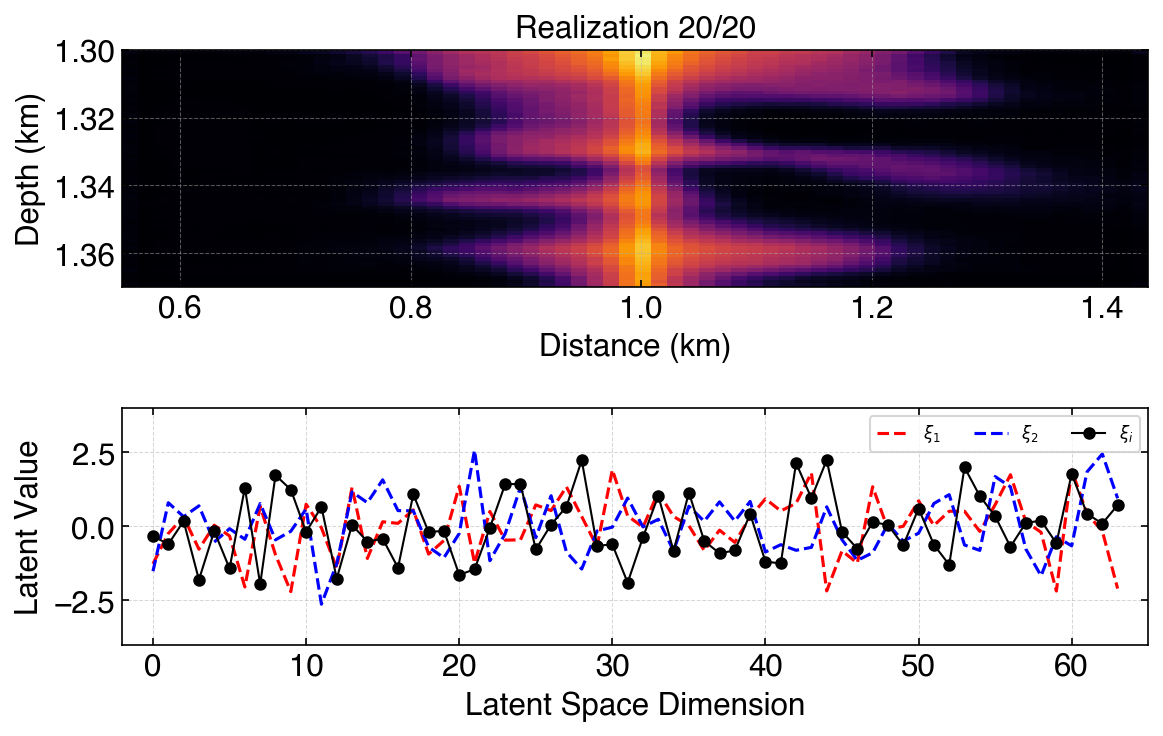

In [41]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), dpi=150)

# --- Subplot 1: Image ---
im = ax1.imshow(generated[0], cmap='inferno', vmin=0, vmax=0.5, aspect='auto', extent=extent)
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Depth (km)')
ax1.set_xticks(np.arange(0.6, res_x[-1]/1000+0.3, 0.2))
ax1.set_yticks(np.arange(res_z[0]/1000, res_z[-1]/1000, 0.02))
ax1.set_xlim(res_x[0]/1000, res_x[-1]/1000)
ax1.set_ylim(res_z[-1]/1000, res_z[0]/1000)
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# --- Subplot 2: Latent Space ---
ax2.plot(z1.detach().cpu().numpy(), 'r--', label=r'$\xi_{1}$')
ax2.plot(z2.detach().cpu().numpy(), 'b--', label=r'$\xi_{2}$')
sc = ax2.plot(z_test[0].cpu().numpy(), marker='o', color='k', label=r'$\xi_{i}$', linewidth=1, markersize=5)[0]
ax2.set_xlim(-2, 65)
ax2.set_ylim(-4, 4)
ax2.legend(fontsize=8, ncol=3, frameon=True, loc='upper right')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
ax2.set_xlabel('Latent Space Dimension')
ax2.set_ylabel('Latent Value')

# --- Update function ---
def update(frame):
    im.set_data(generated[frame])
    sc.set_ydata(z_test[frame].cpu().numpy())
    ax1.set_title(f'Realization {frame+1}/{ntest}')
    return im, sc

# --- Create animation ---
anim = FuncAnimation(fig, update, frames=ntest, interval=300, blit=False)
plt.tight_layout()
anim.save(f"figures/prior_latent_continuity.mp4", fps=4, dpi=300)
plt.show()